In [1526]:
import geopandas as gpd
import pandas as pd
import h3
from shapely.geometry import Polygon

In [1527]:
import os
from dotenv import load_dotenv

load_dotenv()
db_url = os.getenv("DB_URL")

In [1528]:

from sqlalchemy import create_engine 
engine = create_engine(db_url)
ilce_gdf = gpd.read_postgis("SELECT * FROM ilce_temel_kpi;", engine, geom_col="ilce_geom").to_crs(epsg=4326)
ilce_gdf.head()

,ilce,musteri_sayisi,toplam_siparis,ort_kar,toplam_kar,ort_revenue,toplam_revenue,ort_delivery,ilce_geom
0,Nilüfer,11239,17686,132.42,2341940.31,360.89,6382780.11,16.89,"MULTIPOLYGON (((28.74359 40.29972, 28.7422 40...."
1,Osmangazi,4541,6778,123.44,836649.23,352.25,2387538.17,18.53,"MULTIPOLYGON (((29.11404 40.34778, 29.11244 40..."
2,Yıldırım,1348,1758,118.23,207850.72,365.04,641738.92,34.21,"MULTIPOLYGON (((29.14374 40.2515, 29.14335 40...."


In [1529]:
siparis = gpd.read_postgis("SELECT * FROM siparis;", engine, geom_col = "geometry").to_crs(epsg=4326)
siparis.head()

,fid,order_id,latitude,longitude,basket_value,delivery duration,profit,revenue,client_id,geometry
0,0,81512055,40.186535,29.095203,637.6238,22.016667,-149.4062,344.3338,client_79144640,POINT (29.0952 40.18653)
1,1,22267042,40.234744,28.836608,373.0099,9.966667,-17.7624,200.3235,client_24816618,POINT (28.83661 40.23474)
2,2,88017435,40.217676,28.903509,837.5562,7.783333,-30.7442,432.8338,client_16797643,POINT (28.90351 40.21768)
3,3,72989589,40.218052,28.945997,819.1121,15.466667,-86.2728,435.2127,client_78716540,POINT (28.946 40.21805)
4,4,42175004,40.194676,28.988171,187.6337,27.016667,88.7932,221.4132,client_84428508,POINT (28.98817 40.19468)


In [1530]:
ilce_geom = ilce_gdf.union_all()

In [1531]:
#ilce geometrilerinin koordinatlarını çekelim
coords = list(ilce_geom.exterior.coords)
latlngs = [(y, x) for x, y in coords]  


hex_ids = h3.geo_to_cells(ilce_geom.__geo_interface__, res=9)

#ilce geometrilerini 8 çözünürlüklü h3 hücreleriyle dolduralım.
def h3_to_polygon(hid):
    boundary = h3.cell_to_boundary(hid)
    return Polygon([(lng, lat) for lat, lng in boundary])

grid_gdf = gpd.GeoDataFrame({
    "h3_index": list(hex_ids),
    "geometry": [h3_to_polygon(hid) for hid in hex_ids]
}, crs="EPSG:4326")

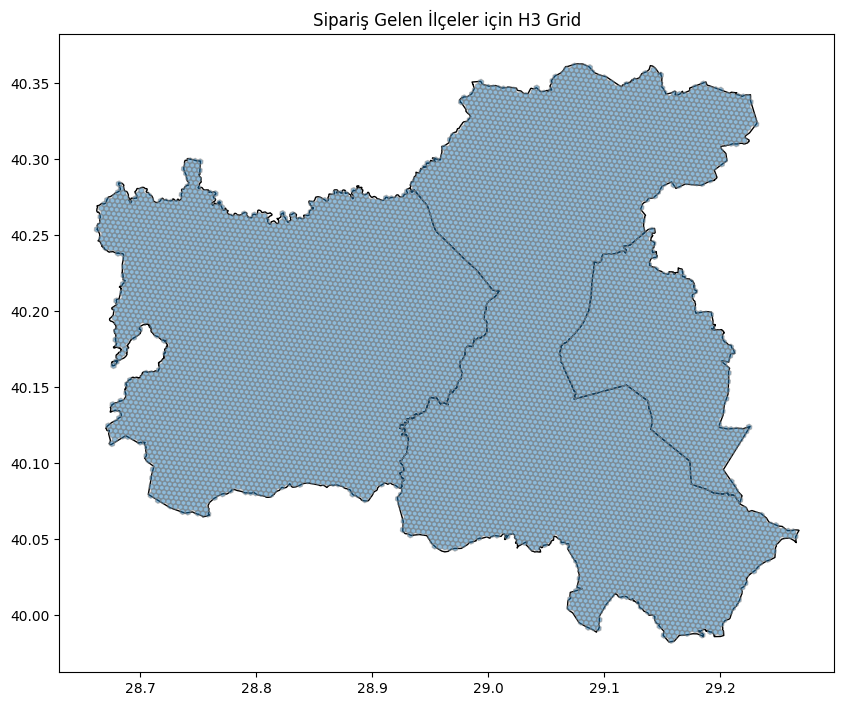

In [1532]:
#kontrol
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
ilce_gdf.plot(ax=ax, color='none', edgecolor='black')
grid_gdf.plot(ax=ax, alpha=0.5, edgecolor='gray')
plt.title("Sipariş Gelen İlçeler için H3 Grid")
plt.show()

In [1533]:
#h3 hücreleri bazında değerleri hesaplayalım.
siparis["h3_index"] = siparis.apply(
    lambda row: h3.latlng_to_cell(row["latitude"], row["longitude"], 9), axis=1
)

h3_stats = siparis.groupby("h3_index").agg(
    sip_adedi_g=("order_id", "count"),
    mus_sayisi_g=("client_id", "nunique"),
    ort_sure_g=("delivery duration", "mean"),
    top_sure_g=("delivery duration", "sum"),
    ort_sepet_g=("basket_value", "mean"),
    top_sepet_g=("basket_value","sum"),
    top_revenue_g=("revenue", "sum"),
    top_kar_g=("profit", "sum")
).reset_index()


grid_gdf = grid_gdf.merge(h3_stats, on="h3_index", how="left")

# NaN olan hücrelere 0 ata
for col in ["sip_adedi_g","mus_sayisi_g","ort_sure_g", "top_sure_g","ort_sepet_g", "top_kar_g","top_sepet_g","top_revenue_g"]:
    grid_gdf[col] = grid_gdf[col].fillna(0)

grid_gdf.head()

,h3_index,geometry,sip_adedi_g,mus_sayisi_g,ort_sure_g,top_sure_g,ort_sepet_g,top_sepet_g,top_revenue_g,top_kar_g
0,891ec96d82fffff,"POLYGON ((29.16409 40.30065, 29.16387 40.29877...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,891ecba7307ffff,"POLYGON ((28.74968 40.25927, 28.74947 40.25739...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,891ecba5673ffff,"POLYGON ((28.70965 40.21669, 28.70943 40.2148,...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,891ecba093bffff,"POLYGON ((28.70346 40.24, 28.70325 40.23812, 2...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,892d34915a7ffff,"POLYGON ((28.89424 40.07947, 28.89402 40.07758...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [1534]:
depo_gdf = gpd.read_postgis("SELECT * FROM warehouse;", engine, geom_col="geometry").to_crs(epsg=4326)
depo_gdf.head()

,fid,city_name,warehouse,lon,lat,geometry
0,0,Bursa,wh_1,28.913683,40.223470,POINT (28.91368 40.22347)
1,1,Bursa,wh_2,29.009756,40.199254,POINT (29.00976 40.19925)
2,2,Bursa,wh_3,28.969918,40.220589,POINT (28.96992 40.22059)
3,3,Bursa,wh_4,29.057349,40.187396,POINT (29.05735 40.1874)
4,4,Bursa,wh_5,28.953623,40.262806,POINT (28.95362 40.26281)


In [1535]:
mahalle_gdf = gpd.read_postgis("SELECT * FROM mahalle_joined;", engine, geom_col = "geometry").to_crs(epsg=4326)
mahalle_gdf.head()

,yil,il,ilce,mahalle,mahalle_kodu,uzunluk,alan,nufus,nufus_yogunlugu,geometry,mahalle_id,agirlikli_ses_skoru
0,2024.0,Bursa,Nilüfer,29 Ekim,140336,6029.236564,1.373578e+06,14587.0,10619.708883,"MULTIPOLYGON (((28.91449 40.21585, 28.91459 40...",4,4.31
1,2024.0,Bursa,Karacabey,Abdullahpaşa,19962,1088.899955,4.963712e+04,1157.0,23309.167507,"MULTIPOLYGON (((28.36141 40.21811, 28.3616 40....",10,1.62
2,2024.0,Bursa,Gürsu,Adaköy,11366,11378.931598,7.029472e+06,1305.0,185.646957,"MULTIPOLYGON (((29.22348 40.24378, 29.23803 40...",11,1.59
3,2024.0,Bursa,Nilüfer,Ahmet Yesevi,11123,4166.951901,1.020135e+06,9021.0,8842.945783,"MULTIPOLYGON (((28.94037 40.27372, 28.94063 40...",17,2.67
4,2024.0,Bursa,İnegöl,Akbaşlar,183709,18217.046886,5.585251e+06,170.0,30.437307,"MULTIPOLYGON (((29.5839 40.10968, 29.58397 40....",23,0.07


In [1536]:
mahalle_kpi  = gpd.read_postgis("SELECT * FROM mahalle_talep_penetrasyon_orani;", engine, geom_col = "geometry").to_crs(epsg=4326)

mahalle_kpi.head()

,mahalle_id,mahalle,ilce,toplam_siparis,musteri_sayisi,nufus,talep_yogunlugu,penetrasyon_orani,geometry,siparis_yog_km2,musteri_yog_km2
0,313,FETHİYEOSB,Nilüfer,14,12,NaN,NaN,NaN,"MULTIPOLYGON (((28.96566 40.2293, 28.96415 40....",6.530058,6.530058
1,464,IŞIKTEPEOSB,Nilüfer,210,123,NaN,NaN,NaN,"MULTIPOLYGON (((28.96188 40.22913, 28.96415 40...",80.575187,80.575187
2,246,Dumlupınar,Nilüfer,2483,1634,28594.0,0.0868,0.0571,"MULTIPOLYGON (((28.83069 40.23083, 28.83073 40...",753.559255,753.559255
3,50,Alacamescit,Osmangazi,22,15,290.0,0.0759,0.0517,"MULTIPOLYGON (((29.06738 40.18107, 29.06728 40...",350.269198,350.269198
4,363,Görükle,Nilüfer,2317,1607,32489.0,0.0713,0.0495,"MULTIPOLYGON (((28.85719 40.268, 28.85804 40.2...",110.175443,110.175443


In [1537]:
mahalle_temel_kpi = gpd.read_postgis("SELECT * FROM temel_kpi_mahalle;", engine, geom_col = "geometry").to_crs(epsg=4326)
mahalle_temel_kpi.head()

,mahalle_id,il,ilce,mahalle,siparis_sayisi,ort_teslim_suresi,toplam_kar,ort_kar,ort_sepet_tutari,ort_revenue,toplam_revenue,nufus,agirlikli_ses_skoru,geometry
0,246,Bursa,Nilüfer,Dumlupınar,2483,16.93,294967.19,118.79,354.43,328.12,814719.35,28594.0,8.45,"MULTIPOLYGON (((28.83069 40.23083, 28.83073 40..."
1,363,Bursa,Nilüfer,Görükle,2317,20.78,258184.85,111.43,338.57,314.46,728610.82,32489.0,9.60,"MULTIPOLYGON (((28.85719 40.268, 28.85804 40.2..."
2,3,Bursa,Nilüfer,23 Nisan,956,16.07,136702.99,142.99,424.18,387.91,370842.52,21042.0,6.22,"MULTIPOLYGON (((28.94019 40.22261, 28.94107 40..."
3,63,Bursa,Nilüfer,Altınşehir,932,10.37,124216.60,133.28,385.63,354.26,330167.25,18830.0,5.57,"MULTIPOLYGON (((28.93659 40.21873, 28.9365 40...."
4,1025,Bursa,Nilüfer,Üçevler,843,14.75,107362.27,127.36,390.64,356.13,300214.40,27559.0,8.15,"MULTIPOLYGON (((28.95229 40.21125, 28.95231 40..."


In [1538]:
import geopandas as gpd
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

#mahalle bazında kpi verilerini birleştirelim
mahalle_full_kpi = mahalle_kpi.merge(mahalle_temel_kpi, on=["mahalle_id","mahalle","ilce","nufus","geometry"], how="left")
# 2. Mahalleleri birleştir  tüm mahalleler + sipariş KPI'ları
mahalle_full = mahalle_gdf.merge(mahalle_full_kpi, on=["mahalle_id","mahalle","ilce","nufus","geometry"], how="left")


In [1539]:
mahalle_full_kpi.head()

,mahalle_id,mahalle,ilce,toplam_siparis,musteri_sayisi,nufus,talep_yogunlugu,penetrasyon_orani,geometry,siparis_yog_km2,musteri_yog_km2,il,siparis_sayisi,ort_teslim_suresi,toplam_kar,ort_kar,ort_sepet_tutari,ort_revenue,toplam_revenue,agirlikli_ses_skoru
0,313,FETHİYEOSB,Nilüfer,14,12,NaN,NaN,NaN,"MULTIPOLYGON (((28.96566 40.2293, 28.96415 40....",6.530058,6.530058,Bursa,14,13.71,1808.26,129.16,327.22,309.27,4329.77,NaN
1,464,IŞIKTEPEOSB,Nilüfer,210,123,NaN,NaN,NaN,"MULTIPOLYGON (((28.96188 40.22913, 28.96415 40...",80.575187,80.575187,Bursa,210,16.20,27991.60,133.29,384.11,354.09,74357.88,NaN
2,246,Dumlupınar,Nilüfer,2483,1634,28594.0,0.0868,0.0571,"MULTIPOLYGON (((28.83069 40.23083, 28.83073 40...",753.559255,753.559255,Bursa,2483,16.93,294967.19,118.79,354.43,328.12,814719.35,8.45
3,50,Alacamescit,Osmangazi,22,15,290.0,0.0759,0.0517,"MULTIPOLYGON (((29.06738 40.18107, 29.06728 40...",350.269198,350.269198,Bursa,22,20.55,2789.65,126.80,370.11,345.47,7600.38,0.04
4,363,Görükle,Nilüfer,2317,1607,32489.0,0.0713,0.0495,"MULTIPOLYGON (((28.85719 40.268, 28.85804 40.2...",110.175443,110.175443,Bursa,2317,20.78,258184.85,111.43,338.57,314.46,728610.82,9.60


In [1540]:
mahalle_full.head()

,yil,il_x,ilce,mahalle,mahalle_kodu,uzunluk,alan,nufus,nufus_yogunlugu,geometry,...,musteri_yog_km2,il_y,siparis_sayisi,ort_teslim_suresi,toplam_kar,ort_kar,ort_sepet_tutari,ort_revenue,toplam_revenue,agirlikli_ses_skoru_y
0,2024.0,Bursa,Nilüfer,29 Ekim,140336,6029.236564,1.373578e+06,14587.0,10619.708883,"MULTIPOLYGON (((28.91449 40.21585, 28.91459 40...",...,371.293037,Bursa,510.0,11.57,72433.95,142.03,411.20,379.01,193296.54,4.31
1,2024.0,Bursa,Karacabey,Abdullahpaşa,19962,1088.899955,4.963712e+04,1157.0,23309.167507,"MULTIPOLYGON (((28.36141 40.21811, 28.3616 40....",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024.0,Bursa,Gürsu,Adaköy,11366,11378.931598,7.029472e+06,1305.0,185.646957,"MULTIPOLYGON (((29.22348 40.24378, 29.23803 40...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024.0,Bursa,Nilüfer,Ahmet Yesevi,11123,4166.951901,1.020135e+06,9021.0,8842.945783,"MULTIPOLYGON (((28.94037 40.27372, 28.94063 40...",...,351.914149,Bursa,359.0,24.90,60032.56,167.22,500.28,457.48,164235.66,2.67
4,2024.0,Bursa,İnegöl,Akbaşlar,183709,18217.046886,5.585251e+06,170.0,30.437307,"MULTIPOLYGON (((29.5839 40.10968, 29.58397 40....",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1541]:
len(mahalle_full)

1074

In [1542]:
len(mahalle_gdf)

1074

In [1543]:
import geopandas as gpd
import pandas as pd

utm = 32635  # metre bazlı koordinat sistemi kesişim alanı için

#  grid ile mahalle_m
grid_m    = grid_gdf.to_crs(utm)          
mahalle_m = mahalle_full.to_crs(utm)       
join_df   = gpd.sjoin(grid_m, mahalle_m, how="left", predicate="intersects")

# Mahalle geometrisini ekle 
join_df["mahalle_geom"] = join_df["index_right"].apply(
    lambda i: mahalle_m.loc[i, "geometry"] if pd.notna(i) and i in mahalle_m.index else None
)

# 3) Kesişim alanını hesapla
join_df["kesisim_alan"] = join_df.apply(
    lambda row: row["geometry"].intersection(row["mahalle_geom"]).area if row["mahalle_geom"] else 0,
    axis=1
)

# 4) En baskın mahalleyi seç
best = join_df.sort_values("kesisim_alan", ascending=False).drop_duplicates("h3_index")

# 5) MERGE edeceğin geometrinin CRS'ini geri 4326'ya çevir
best = best.to_crs(4326)                   

# 6) Grid’e geri bağla (senin yapınla aynı)
grid_gdf = grid_gdf.drop(columns=["geometry"])
grid_gdf = grid_gdf.merge(
    best[[
        "ilce","h3_index","mahalle","toplam_siparis","talep_yogunlugu","nufus","geometry","siparis_yog_km2"
        ]],
        on="h3_index", how="left"
        )

# 7) GeoDataFrame olarak yeniden tanımla
grid_gdf = gpd.GeoDataFrame(grid_gdf, geometry="geometry", crs="EPSG:4326")



In [1544]:
grid_gdf.head()

,h3_index,sip_adedi_g,mus_sayisi_g,ort_sure_g,top_sure_g,ort_sepet_g,top_sepet_g,top_revenue_g,top_kar_g,ilce,mahalle,toplam_siparis,talep_yogunlugu,nufus,geometry,siparis_yog_km2
0,891ec96d82fffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Osmangazi,Avdancık,NaN,NaN,457.0,"POLYGON ((29.16409 40.30065, 29.16387 40.29877...",NaN
1,891ecba7307ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,Konaklı,NaN,NaN,1098.0,"POLYGON ((28.74968 40.25927, 28.74947 40.25739...",NaN
2,891ecba5673ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,Çatalağıl,NaN,NaN,176.0,"POLYGON ((28.70965 40.21669, 28.70943 40.2148,...",NaN
3,891ecba093bffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,Badırga,NaN,NaN,344.0,"POLYGON ((28.70346 40.24, 28.70325 40.23812, 2...",NaN
4,892d34915a7ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,Kadriye,NaN,NaN,125.0,"POLYGON ((28.89424 40.07947, 28.89402 40.07758...",NaN


In [1545]:
grid_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [1546]:
import osmnx as ox, networkx as nx, numpy as np
import pandas as pd, geopandas as gpd
from shapely.geometry import Point

# 1) Çalışma alanı
study_area = ilce_gdf.to_crs(4326).union_all().buffer(0.01) # yaklaşık 1 km buffer 
G = ox.graph_from_polygon(study_area, network_type="drive_service")




# 2) Yükseklik ve eğim
dem_path = "../data/raw/dem.tif"

ox.elevation.add_node_elevations_raster(G, dem_path)
ox.elevation.add_edge_grades(G, add_absolute=True)   

# 3) Varsayılan hızlar
ox.add_edge_speeds(G)  

# 4) Parametreler
UP_P_PER_PC        = 0.015  # %1 yokuş için +0.5% ceza
DOWN_B_PER_PC      = 0.002  # %1 iniş için -0.2% bonus
GRADE_CLIP_PC      = 12.0   #eğim 12 ye kadar al 
MULT_MIN, MULT_MAX = 0.7, 2.0 #en fazla 2 kat artsın, %30 azalsın

# 5) Yol tipine göre motosiklet hız profili + eğim etkisi
for u, v, k, d in G.edges(keys=True, data=True):
    base_speed = float(d.get("speed_kph", 30.0))
    highway    = d.get("highway", "")

    # Yol tipine göre hız çarpanı
    if highway in ["residential", "living_street", "service"]:
        sp_kph = base_speed * 1.2   # dar sokaklarda motor avantajlı
    elif highway in ["primary", "secondary", "tertiary"]:
        sp_kph = base_speed * 1.0   # ana yolda normal
    elif highway in ["motorway", "trunk"]:
        sp_kph = base_speed * 0.9   # otoyolda biraz dezavantaj
    else:
        sp_kph = base_speed * 1.0

    # 📏 Temel süre
    length_m = float(d.get("length", 0.0))
    t_free   = length_m / (sp_kph * 1000.0/3600.0) if length_m > 0 else 0.0

    # eğim etkisi
    grade_pct = float(np.clip(float(d.get("grade", 0.0)) * 100.0,
                              -GRADE_CLIP_PC, GRADE_CLIP_PC))
    up, down  = max(0.0, grade_pct), max(0.0, -grade_pct)
    mult      = 1.0 + UP_P_PER_PC*up - DOWN_B_PER_PC*down
    mult      = float(np.clip(mult, MULT_MIN, MULT_MAX))

    # Final motor süresi
    d["travel_time_moto"] = t_free * mult

# 6) Diğer edge travel time hesapları 
ox.add_edge_travel_times(G)

In [1547]:
# Grid cmerkezleri hesaplayalım
grid_cent = grid_gdf.to_crs(32635).copy()
grid_cent["centroid"] = grid_cent.geometry.centroid
grid_cent = grid_cent.set_geometry("centroid").to_crs(4326)

# Grid merkezleri için en yakın düğüm
grid_cent["node"] = ox.distance.nearest_nodes(
    G,
    grid_cent.geometry.x.values,
    grid_cent.geometry.y.values
)

# Depoların en yakın düğümü
depo_gdf = depo_gdf.to_crs(4326).copy()
depo_gdf["node"] = ox.distance.nearest_nodes(
    G,
    depo_gdf.geometry.x.values,
    depo_gdf.geometry.y.values
)


In [1548]:
CUTOFF   = 45 * 60     # 45 dk üstünü arama
WEIGHT   = "travel_time_moto"   # motosiklet için
        

#H3 merkez nodelarını hesapla 
grid_cent["node"] = ox.distance.nearest_nodes(
    G,
    grid_cent.geometry.x.values,
    grid_cent.geometry.y.values
)

rows = []
for _, d in depo_gdf.iterrows():
    src = d["node"]


    # Dijkstra: 
    lengths = nx.single_source_dijkstra_path_length(G, src, weight=WEIGHT, cutoff=CUTOFF)
    if not lengths:
        continue

    # Her hücreye ait süre  ve hangi depodan geldiği eklenmesi
    in_sub = grid_cent[grid_cent["node"].isin(lengths.keys())][["h3_index","node"]].copy()
    if in_sub.empty:
        continue

    in_sub["depot_id"] = d["warehouse"]
    in_sub["t_sec"]    = in_sub["node"].map(lengths).astype(float)
    rows.append(in_sub[["depot_id","h3_index","t_sec"]])
#Tüm depolar için erişilebilen H3 hücreleri ve süreler
tt = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["depot_id","h3_index","t_sec"])

# Her H3 için en hızlı depo ve süre seçimi
best = tt.loc[tt.groupby("h3_index")["t_sec"].idxmin()].rename(
    columns={"depot_id":"best_depot","t_sec":"t_sec_min"}
)

# Grid'e yaz
grid_gdf = grid_gdf.merge(best[["h3_index","best_depot","t_sec_min"]], on="h3_index", how="left")
grid_gdf["t_min"]  = grid_gdf["t_sec_min"] / 60.0



In [1549]:
grid_gdf.head()

,h3_index,sip_adedi_g,mus_sayisi_g,ort_sure_g,top_sure_g,ort_sepet_g,top_sepet_g,top_revenue_g,top_kar_g,ilce,mahalle,toplam_siparis,talep_yogunlugu,nufus,geometry,siparis_yog_km2,best_depot,t_sec_min,t_min
0,891ec96d82fffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Osmangazi,Avdancık,NaN,NaN,457.0,"POLYGON ((29.16409 40.30065, 29.16387 40.29877...",NaN,wh_5,1408.441716,23.474029
1,891ecba7307ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,Konaklı,NaN,NaN,1098.0,"POLYGON ((28.74968 40.25927, 28.74947 40.25739...",NaN,wh_9,742.724949,12.378749
2,891ecba5673ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,Çatalağıl,NaN,NaN,176.0,"POLYGON ((28.70965 40.21669, 28.70943 40.2148,...",NaN,wh_9,770.385033,12.839751
3,891ecba093bffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,Badırga,NaN,NaN,344.0,"POLYGON ((28.70346 40.24, 28.70325 40.23812, 2...",NaN,wh_9,1059.441943,17.657366
4,892d34915a7ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,Kadriye,NaN,NaN,125.0,"POLYGON ((28.89424 40.07947, 28.89402 40.07758...",NaN,wh_6,1355.782473,22.596375


In [1550]:
#talep yogunlugu olmayan mahallelerin talep yogunlugunu ilce ile dolduralım
ilce_kpi  = gpd.read_postgis("SELECT * FROM ilce_nufus_kpi;", engine, geom_col = "geometry").to_crs(epsg=4326)

ilce_kpi.head()

,ilce,musteri_sayisi,toplam_siparis,nufus,nufus_yogunlugu,penetrasyon_orani,talep_yogunlugu,baskin_yas_grubu,geometry
0,Nilüfer,11239,17686,561730,1108.5406,0.0200,0.0315,35-49,"MULTIPOLYGON (((28.74359 40.29972, 28.7422 40...."
1,Osmangazi,4541,6778,885441,1418.5404,0.0051,0.0077,35-49,"MULTIPOLYGON (((29.11404 40.34778, 29.11244 40..."
2,Yıldırım,1348,1758,654998,5083.3237,0.0021,0.0027,35-49,"MULTIPOLYGON (((29.14374 40.2515, 29.14335 40...."


In [1551]:
# İlçe talep yoğunluklarını dictionary olarak tanımlayalım
ilce_talep_dict = {
    "Nilüfer": 0.0315,
    "Osmangazi": 0.0077,
    "Yıldırım": 0.0021
}

# NaN olanları ilçe ortalamasıyla doldur listede yoksa olduğu gibi bırakıyoruz
grid_gdf["talep_yogunlugu"] = grid_gdf.apply(
    lambda row: ilce_talep_dict.get(row["ilce"], row["talep_yogunlugu"]) 
    if pd.isna(row["talep_yogunlugu"]) else row["talep_yogunlugu"],
    axis=1
)

In [1552]:
#talep yogunlugunu normalize edelim
from sklearn.preprocessing import MinMaxScaler 
scaler = MinMaxScaler()
grid_gdf["talep_yogunlugu_norm"] = scaler.fit_transform(grid_gdf[["talep_yogunlugu"]])

In [1553]:
#mahalle bazında talep yogunlugunu ceza olarak süreye ekleyelim.
gamma = 0.5  # etki katsayısı 
grid_gdf["t_min_cezali"] = grid_gdf["t_min"] * (1 + gamma * grid_gdf["talep_yogunlugu_norm"])

In [1554]:
grid_gdf.head()

,h3_index,sip_adedi_g,mus_sayisi_g,ort_sure_g,top_sure_g,ort_sepet_g,top_sepet_g,top_revenue_g,top_kar_g,ilce,...,toplam_siparis,talep_yogunlugu,nufus,geometry,siparis_yog_km2,best_depot,t_sec_min,t_min,talep_yogunlugu_norm,t_min_cezali
0,891ec96d82fffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Osmangazi,...,NaN,0.0077,457.0,"POLYGON ((29.16409 40.30065, 29.16387 40.29877...",NaN,wh_5,1408.441716,23.474029,0.087659,24.502879
1,891ecba7307ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,NaN,0.0315,1098.0,"POLYGON ((28.74968 40.25927, 28.74947 40.25739...",NaN,wh_9,742.724949,12.378749,0.362168,14.620345
2,891ecba5673ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,NaN,0.0315,176.0,"POLYGON ((28.70965 40.21669, 28.70943 40.2148,...",NaN,wh_9,770.385033,12.839751,0.362168,15.164826
3,891ecba093bffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,NaN,0.0315,344.0,"POLYGON ((28.70346 40.24, 28.70325 40.23812, 2...",NaN,wh_9,1059.441943,17.657366,0.362168,20.854836
4,892d34915a7ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,NaN,0.0315,125.0,"POLYGON ((28.89424 40.07947, 28.89402 40.07758...",NaN,wh_6,1355.782473,22.596375,0.362168,26.688221


In [1555]:
# Depo bazında sipariş adedi ve toplam süre
depo_kpi = grid_gdf.groupby("best_depot").agg({
    "sip_adedi_g": "sum",
    "top_sure_g": "sum"
}).reset_index()

# Ortalama süreyi hesapla
depo_kpi["ort_teslimat_suresi"] = depo_kpi["top_sure_g"] / depo_kpi["sip_adedi_g"]

total_siparis = depo_kpi["sip_adedi_g"].sum()
depo_kpi["depo_oran"] = depo_kpi["sip_adedi_g"] / total_siparis

print(depo_kpi)

  best_depot  sip_adedi_g     top_sure_g  ort_teslimat_suresi  depo_oran
0       wh_1       2962.0   37175.250000            12.550726   0.112959
1       wh_2       2827.0   48306.933333            17.087702   0.107810
2       wh_3       3840.0   51540.516667            13.422010   0.146442
3       wh_4       2391.0   47885.300000            20.027311   0.091183
4       wh_5       1976.0   49015.416667            24.805373   0.075357
5       wh_6       2945.0   48587.766667            16.498393   0.112310
6       wh_7       1243.0   48116.750000            38.710177   0.047403
7       wh_8       2432.0   44223.133333            18.183854   0.092747
8       wh_9       5606.0  109652.966667            19.559930   0.213790


In [1556]:
#depo siparis orani ile ortalama teslimat süresi arasında nasıl bir ilişki var?
from sklearn.linear_model import LinearRegression
import numpy as np

X = depo_kpi[["depo_oran"]].values
y = depo_kpi["ort_teslimat_suresi"].values

model = LinearRegression()
model.fit(X, y)

print("Katsayı:", model.coef_[0], "Intercept:", model.intercept_)


Katsayı: -90.44046049152688 Intercept: 30.14288168106667


In [1557]:
#deponun ortalama teslimat süresine göre ceza faktörü uygulayalım.
def ceza_faktor(row):
    if row["ort_teslimat_suresi"] <= 15:
        return 0.3
    elif row["ort_teslimat_suresi"] <= 25:
        return 0.4
    else:
        return 0.5

depo_kpi["ceza_faktor"] = depo_kpi.apply(ceza_faktor, axis=1)



#her deponun yükünü sürelere ceza olarak ekleyelim
from sklearn.preprocessing import MinMaxScaler

# Normalize et
scaler = MinMaxScaler()
depo_kpi["depo_oran_norm"] = scaler.fit_transform(depo_kpi[["depo_oran"]])

# 4) Grid'e geri yaz
grid_gdf = grid_gdf.merge(depo_kpi[["best_depot", "depo_oran_norm","ceza_faktor"]],
                          on="best_depot", how="left")

# 5) Ceza uygula

grid_gdf["t_depo_cezali"] = grid_gdf["t_min_cezali"] * (1 + grid_gdf["ceza_faktor"] * grid_gdf["depo_oran_norm"])


grid_gdf.head()

,h3_index,sip_adedi_g,mus_sayisi_g,ort_sure_g,top_sure_g,ort_sepet_g,top_sepet_g,top_revenue_g,top_kar_g,ilce,...,geometry,siparis_yog_km2,best_depot,t_sec_min,t_min,talep_yogunlugu_norm,t_min_cezali,depo_oran_norm,ceza_faktor,t_depo_cezali
0,891ec96d82fffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Osmangazi,...,"POLYGON ((29.16409 40.30065, 29.16387 40.29877...",NaN,wh_5,1408.441716,23.474029,0.087659,24.502879,0.168004,0.4,26.149508
1,891ecba7307ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,"POLYGON ((28.74968 40.25927, 28.74947 40.25739...",NaN,wh_9,742.724949,12.378749,0.362168,14.620345,1.000000,0.4,20.468483
2,891ecba5673ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,"POLYGON ((28.70965 40.21669, 28.70943 40.2148,...",NaN,wh_9,770.385033,12.839751,0.362168,15.164826,1.000000,0.4,21.230757
3,891ecba093bffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,"POLYGON ((28.70346 40.24, 28.70325 40.23812, 2...",NaN,wh_9,1059.441943,17.657366,0.362168,20.854836,1.000000,0.4,29.196770
4,892d34915a7ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,"POLYGON ((28.89424 40.07947, 28.89402 40.07758...",NaN,wh_6,1355.782473,22.596375,0.362168,26.688221,0.390099,0.4,30.852636


In [1558]:

import h3

#h3 hücre değerlerini 1 aşama yumuşatalım. Yani çevresindekilere göre etkilensin
def smooth_time(row, grid_dict, k=1):
    h3_id = row["h3_index"]
    neighbors = h3.grid_disk(h3_id, k)  
    neighbor_times = [grid_dict.get(n) for n in neighbors if grid_dict.get(n) is not None]
    
    if row["t_depo_cezali"] is not None:  # kendisini de ekle
        neighbor_times.append(row["t_depo_cezali"])
    
    if len(neighbor_times) > 0:
        return np.mean(neighbor_times)
    else:
        return row["t_depo_cezali"]

# sözlük
grid_dict = dict(zip(grid_gdf["h3_index"], grid_gdf["t_depo_cezali"]))

# yeni sütun
grid_gdf["t_min_smooth"] = grid_gdf.apply(lambda r: smooth_time(r, grid_dict, k=1), axis=1)

In [1559]:
grid_gdf.head()

,h3_index,sip_adedi_g,mus_sayisi_g,ort_sure_g,top_sure_g,ort_sepet_g,top_sepet_g,top_revenue_g,top_kar_g,ilce,...,siparis_yog_km2,best_depot,t_sec_min,t_min,talep_yogunlugu_norm,t_min_cezali,depo_oran_norm,ceza_faktor,t_depo_cezali,t_min_smooth
0,891ec96d82fffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Osmangazi,...,NaN,wh_5,1408.441716,23.474029,0.087659,24.502879,0.168004,0.4,26.149508,27.066280
1,891ecba7307ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,NaN,wh_9,742.724949,12.378749,0.362168,14.620345,1.000000,0.4,20.468483,20.649118
2,891ecba5673ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,NaN,wh_9,770.385033,12.839751,0.362168,15.164826,1.000000,0.4,21.230757,21.160614
3,891ecba093bffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,NaN,wh_9,1059.441943,17.657366,0.362168,20.854836,1.000000,0.4,29.196770,28.667519
4,892d34915a7ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,NaN,wh_6,1355.782473,22.596375,0.362168,26.688221,0.390099,0.4,30.852636,31.585821


In [1560]:
#t_min_smootha göre kategorize
def zonlama0(t_min_smooth):
    if pd.isna(t_min_smooth):
        return "diger"
    elif t_min_smooth <= 5:
        return "0-5 dk"
    elif t_min_smooth <= 10:
        return "5-10 dk"
    elif t_min_smooth <= 15:
        return "10-15 dk"
    else:
        return "15+ dk"

grid_gdf["erisim_zonu_harita0"] = grid_gdf["t_min_smooth"].apply(zonlama0)

In [1561]:
#gerçek süreye göre kategorize
def zonlama(t_depo_cezali):
    if pd.isna(t_depo_cezali):
        return "diger"
    elif t_depo_cezali <= 5:
        return "0-5 dk"
    elif t_depo_cezali <= 10:
        return "5-10 dk"
    elif t_depo_cezali <= 15:
        return "15 dk"
    else:
        return "15+ dk"

grid_gdf["erisim_zonu"] = grid_gdf["t_depo_cezali"].apply(zonlama)

In [1562]:
# Depo bazında sipariş adedi ve toplam süre
depo_stats = grid_gdf.groupby("best_depot").agg({
    "sip_adedi_g": "sum",
    "top_sure_g": "sum"
}).reset_index()

# Ortalama süreyi hesapla
depo_stats["ortalama_teslimat_suresi"] = depo_stats["top_sure_g"] / depo_stats["sip_adedi_g"]

print(depo_stats)

  best_depot  sip_adedi_g     top_sure_g  ortalama_teslimat_suresi
0       wh_1       2962.0   37175.250000                 12.550726
1       wh_2       2827.0   48306.933333                 17.087702
2       wh_3       3840.0   51540.516667                 13.422010
3       wh_4       2391.0   47885.300000                 20.027311
4       wh_5       1976.0   49015.416667                 24.805373
5       wh_6       2945.0   48587.766667                 16.498393
6       wh_7       1243.0   48116.750000                 38.710177
7       wh_8       2432.0   44223.133333                 18.183854
8       wh_9       5606.0  109652.966667                 19.559930


In [1563]:


tt = pd.concat(rows, ignore_index=True)[["depot_id","h3_index","t_sec"]]
tt = tt.merge(depo_kpi[["best_depot","ceza_faktor","depo_oran_norm"]],
              left_on="depot_id", right_on="best_depot", how="left")
tt["t_sec_pen"] = tt["t_sec"] * (1 + tt["ceza_faktor"] * tt["depo_oran_norm"])

best_pen = tt.loc[tt.groupby("h3_index")["t_sec_pen"].idxmin()].rename(
    columns={"depot_id":"best_depot_pen","t_sec_pen":"t_sec_pen_min"}
)



grid_gdf = grid_gdf.merge(
    best_pen[["h3_index","best_depot_pen","t_sec_pen_min"]],
    on="h3_index", how="left"
)
grid_gdf["t_min_pen"] = grid_gdf["t_sec_pen_min"] / 60.0

changed = (grid_gdf["best_depot"] != grid_gdf["best_depot_pen"]).sum()
print(f"{changed} hücre cezalı süreye göre farklı depoya atandı.")


3183 hücre cezalı süreye göre farklı depoya atandı.


In [1564]:
mask = grid_gdf["best_depot"] != grid_gdf["best_depot_pen"]
changed_with_orders = grid_gdf[mask & (grid_gdf["sip_adedi_g"] > 0)]

print(f"{len(changed_with_orders)} hücre hem farklı depoya atandı hem sipariş içeriyor.")


17 hücre hem farklı depoya atandı hem sipariş içeriyor.


In [1565]:
# Depo bazında sipariş adedi ve toplam süre
depo_bulunan = grid_gdf.groupby("best_depot_pen").agg({
    "sip_adedi_g": "sum",
    "top_sure_g": "sum"
}).reset_index()

# Ortalama süreyi hesapla
depo_bulunan["ortalama_teslimat_suresi"] = depo_bulunan["top_sure_g"] / depo_bulunan["sip_adedi_g"]

print(depo_bulunan)

  best_depot_pen  sip_adedi_g     top_sure_g  ortalama_teslimat_suresi
0           wh_1       3252.0   42191.016667                 12.973867
1           wh_2       2791.0   47531.200000                 17.030168
2           wh_3       3683.0   48863.716667                 13.267368
3           wh_4       2338.0   46623.500000                 19.941617
4           wh_5       2005.0   49868.566667                 24.872103
5           wh_6       2810.0   46441.416667                 16.527195
6           wh_7       1320.0   49880.350000                 37.788144
7           wh_8       2431.0   43884.116667                 18.051879
8           wh_9       5592.0  109220.150000                 19.531500


In [1566]:
# İlçe talep yoğunluklarını dictionary olarak tanımlayalım
ilce_yog_dict = {
    "Nilüfer": 34.90,
    "Osmangazi": 10.86,
    "Yıldırım": 13.64
}

# NaN olanları ilçe ortalamasıyla doldur, listede yoksa olduğu gibi bırak
grid_gdf["siparis_yog_km2"] = grid_gdf.apply(
    lambda row: ilce_yog_dict.get(row["ilce"], row["siparis_yog_km2"]) 
    if pd.isna(row["siparis_yog_km2"]) else row["siparis_yog_km2"],
    axis=1
)

In [1567]:
grid_gdf.head()

,h3_index,sip_adedi_g,mus_sayisi_g,ort_sure_g,top_sure_g,ort_sepet_g,top_sepet_g,top_revenue_g,top_kar_g,ilce,...,t_min_cezali,depo_oran_norm,ceza_faktor,t_depo_cezali,t_min_smooth,erisim_zonu_harita0,erisim_zonu,best_depot_pen,t_sec_pen_min,t_min_pen
0,891ec96d82fffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Osmangazi,...,24.502879,0.168004,0.4,26.149508,27.066280,15+ dk,15+ dk,wh_7,1476.897489,24.614958
1,891ecba7307ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,14.620345,1.000000,0.4,20.468483,20.649118,15+ dk,15+ dk,wh_9,1039.814929,17.330249
2,891ecba5673ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,15.164826,1.000000,0.4,21.230757,21.160614,15+ dk,15+ dk,wh_9,1078.539046,17.975651
3,891ecba093bffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,20.854836,1.000000,0.4,29.196770,28.667519,15+ dk,15+ dk,wh_5,1469.203082,24.486718
4,892d34915a7ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,26.688221,0.390099,0.4,30.852636,31.585821,15+ dk,15+ dk,wh_6,1567.337987,26.122300


In [1568]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
grid_gdf["sip_yog_norm"] = scaler.fit_transform(grid_gdf[["siparis_yog_km2"]])


gamma = 0.5  # deneme katsayısı 
grid_gdf["t_sec_pen_ceza"] = grid_gdf["t_sec_pen_min"] * (1 + gamma * grid_gdf["sip_yog_norm"])
grid_gdf["t_min_pen_ceza"] = grid_gdf["t_sec_pen_ceza"] / 60.0
grid_gdf.head()

,h3_index,sip_adedi_g,mus_sayisi_g,ort_sure_g,top_sure_g,ort_sepet_g,top_sepet_g,top_revenue_g,top_kar_g,ilce,...,t_depo_cezali,t_min_smooth,erisim_zonu_harita0,erisim_zonu,best_depot_pen,t_sec_pen_min,t_min_pen,sip_yog_norm,t_sec_pen_ceza,t_min_pen_ceza
0,891ec96d82fffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Osmangazi,...,26.149508,27.066280,15+ dk,15+ dk,wh_7,1476.897489,24.614958,0.006062,1481.373777,24.689563
1,891ecba7307ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,20.468483,20.649118,15+ dk,15+ dk,wh_9,1039.814929,17.330249,0.020661,1050.556883,17.509281
2,891ecba5673ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,21.230757,21.160614,15+ dk,15+ dk,wh_9,1078.539046,17.975651,0.020661,1089.681045,18.161351
3,891ecba093bffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,29.196770,28.667519,15+ dk,15+ dk,wh_5,1469.203082,24.486718,0.020661,1484.380891,24.739682
4,892d34915a7ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,30.852636,31.585821,15+ dk,15+ dk,wh_6,1567.337987,26.122300,0.020661,1583.529592,26.392160


In [1569]:
import numpy as np
import pandas as pd
import h3

def smooth_time(row, grid_dict, k=1):
    h3_id = row["h3_index"]
    neighbors = h3.grid_disk(h3_id, k)  
    neighbor_times = [grid_dict.get(n) for n in neighbors if grid_dict.get(n) is not None]
    
    # Kendisi varsa ekle
    if pd.notna(row["t_min_pen_ceza"]):
        neighbor_times.append(row["t_min_pen_ceza"])
    
    # NaN'leri temizle
    neighbor_times = [t for t in neighbor_times if pd.notna(t)]
    
    if len(neighbor_times) > 0:
        return np.mean(neighbor_times)
    else:
        return row["t_min_pen_ceza"]

# sözlük
grid_dict = dict(zip(grid_gdf["h3_index"], grid_gdf["t_min_pen_ceza"]))

# yeni sütun
grid_gdf["t_min_pen_smooth"] = grid_gdf.apply(lambda r: smooth_time(r, grid_dict, k=1), axis=1)


In [1570]:
# kategorize
def zonlama3(t_min_pen_ceza):
    if pd.isna(t_min_pen_ceza):
        return "diger"
    elif t_min_pen_ceza <= 5:
        return "0-5 dk"
    elif t_min_pen_ceza <= 10:
        return "5-10 dk"
    elif t_min_pen_ceza <= 15:
        return "10-15 dk"
    else:
        return "15+ dk"

grid_gdf["erisim_zonu_2"] = grid_gdf["t_min_pen_ceza"].apply(zonlama3)

In [1571]:
# kategorize
def zonlama4(t_min_pen_smooth):
    if pd.isna(t_min_pen_smooth):
        return "diger"
    elif t_min_pen_smooth <= 5:
        return "0-5 dk"
    elif t_min_pen_smooth <= 10:
        return "5-10 dk"
    elif t_min_pen_smooth <= 15:
        return "10-15 dk"
    else:
        return "15+ dk"

grid_gdf["erisim_zonu_harita1"] = grid_gdf["t_min_pen_smooth"].apply(zonlama4)

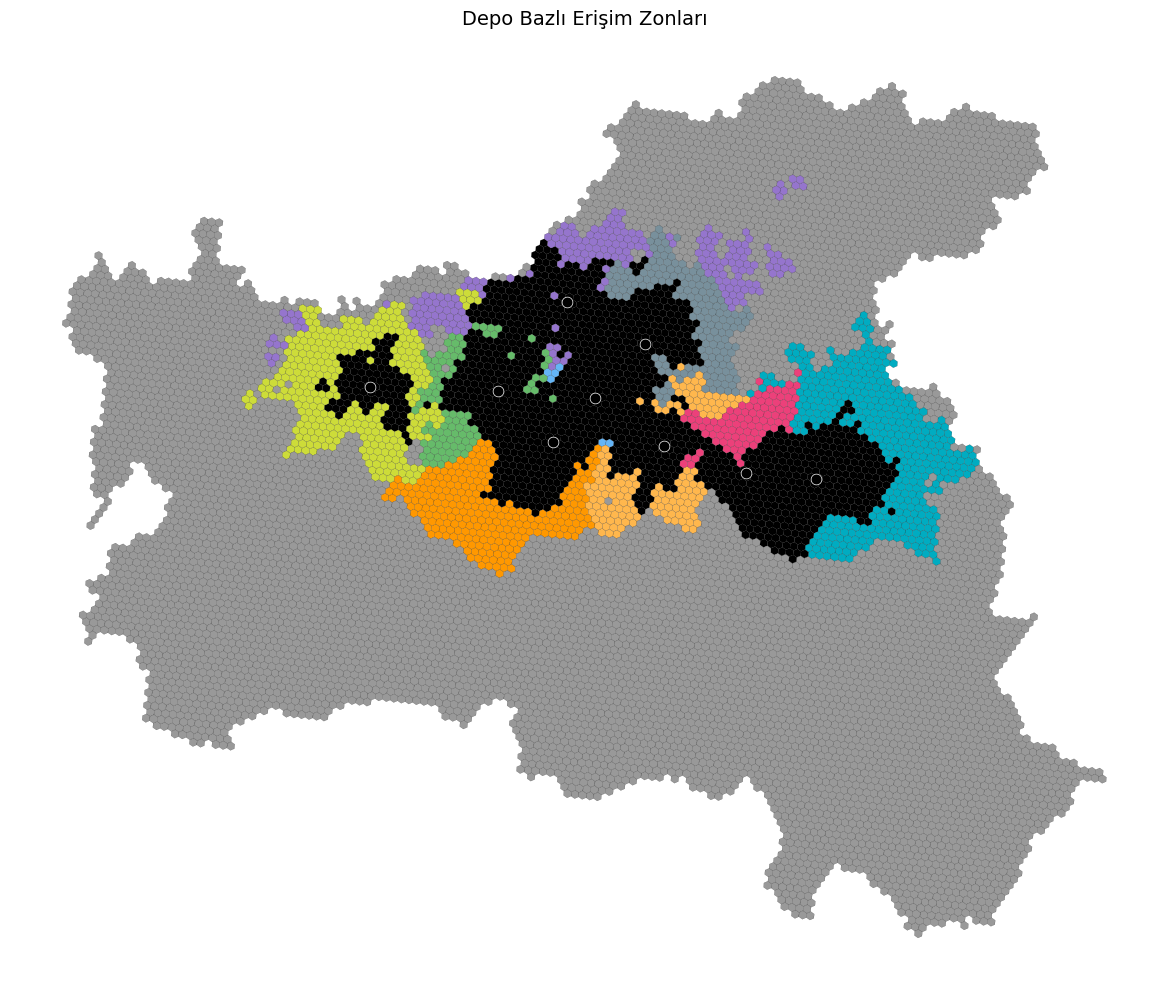

In [ ]:
#DENEME
depo_paleti = {
    "wh_1": {
        "0-5 dk": "#000000",     
        "5-10 dk": "#66bb6a",    
        "10-20 dk": "#1b5e20",   
        "20+ dk": "#000000"      
    },
    "wh_2": {
        "0-5 dk": "#000000",     
        "5-10 dk": "#ffb74d",    
        "10-20 dk": "#d32f2f",   
        "20+ dk": "#000000"      
    },
    "wh_3": {
        "0-5 dk": "#000000",     
        "5-10 dk": "#64b5f6",    
        "10-20 dk": "#0d47a1",   
        "20+ dk": "#000000"      
    },
    "wh_4": {
        "0-5 dk": "#000000",     
        "5-10 dk": "#ec407a",    
        "10-20 dk": "#880e4f",   
        "20+ dk": "#000000"      
    },
    "wh_5": {
        "0-5 dk": "#000000",     
        "5-10 dk": "#9575cd",    
        "10-20 dk": "#512da8",   
        "20+ dk": "#000000"      
    },
    "wh_6": {
        "0-5 dk": "#000000",     
        "5-10 dk": "#ff9800",    
        "10-20 dk": "#e65100",   
        "20+ dk": "#000000"      
    },
    "wh_7": {
        "0-5 dk": "#000000",     
        "5-10 dk": "#00acc1",    
        "10-20 dk": "#006064",   
        "20+ dk": "#000000"      
    },
    "wh_8": {
        "0-5 dk": "#000000",     
        "5-10 dk": "#78909c",    
        "10-20 dk": "#37474f",   
        "20+ dk": "#000000"      
    },
    "wh_9": {
        "0-5 dk": "#000000",     
        "5-10 dk": "#cddc39",    
        "10-20 dk": "#827717",   
        "20+ dk": "#000000"      
    }
}

def grid_rengi(row):
    depo = row["best_depot_pen"]
    zon = row["erisim_zonu_hari"]
    return depo_paleti.get(depo, {}).get(zon, "#999999")  # default daha koyu gri

grid_gdf["color"] = grid_gdf.apply(grid_rengi, axis=1)


grid_gdf["color"] = grid_gdf.apply(grid_rengi, axis=1)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

# Gridleri çiz
grid_gdf.plot(color=grid_gdf["color"], ax=ax, edgecolor="black", linewidth=0.1)

# Depoları ekle

depo_gdf.plot(ax=ax, color="black", markersize=60, marker="o", edgecolor="white", linewidth=0.5)

plt.title("Depo Bazlı Erişim Zonları", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [1573]:
#servis alanı bazında kpilar 
# Her depo + zon için kapsanan mahalle isimlerini listele
mahalle_list = (
    grid_gdf.groupby(["best_depot_pen", "erisim_zonu_2"])["mahalle"]
    .unique()                # mahalleleri liste halinde getir
    .reset_index()
    .rename(columns={"mahalle": "mahalle_listesi"})
)

print(mahalle_list.head())


  best_depot_pen erisim_zonu_2  \
0           wh_1        0-5 dk   
1           wh_1      10-15 dk   
2           wh_1       5-10 dk   
3           wh_2        0-5 dk   
4           wh_2      10-15 dk   

                                     mahalle_listesi  
0  [Görükle, MİNARELİÇAVUŞOSB, Altınşehir, Özlüce...  
1                         [Tahtalı, Ürünlü, Görükle]  
2  [Yaylacık, Ürünlü, Özlüce, Görükle, Doğanköy, ...  
3  [Dikkaldırım, İnkaya, Odunluk, Çamlıca, Doburc...  
4  [Doğancı, İnkaya, Yiğitali, Gökçeören, Dağyeni...  


In [1574]:
depo_kpii = (
    grid_gdf.groupby("best_depot_pen").agg(
        toplam_siparis=("sip_adedi_g", "sum"),
        toplam_sure=("top_sure_g", "sum"),
        mahalle_sayisi=("mahalle", "nunique"),
        musteri_sayisi=("mus_sayisi_g","sum")
    )
    .reset_index()
)

# Ortalama süreyi hesapla
depo_kpii["ortalama_sure"] = depo_kpii["toplam_sure"] / depo_kpii["toplam_siparis"]


print(depo_kpii)

  best_depot_pen  toplam_siparis    toplam_sure  mahalle_sayisi  \
0           wh_1          3252.0   42191.016667              19   
1           wh_2          2791.0   47531.200000              43   
2           wh_3          3683.0   48863.716667              15   
3           wh_4          2338.0   46623.500000              83   
4           wh_5          2005.0   49868.566667              71   
5           wh_6          2810.0   46441.416667              34   
6           wh_7          1320.0   49880.350000              82   
7           wh_8          2431.0   43884.116667              28   
8           wh_9          5592.0  109220.150000              31   

   musteri_sayisi  ortalama_sure  
0          2035.0      12.973867  
1          1862.0      17.030168  
2          2470.0      13.267368  
3          1618.0      19.941617  
4          1372.0      24.872103  
5          1712.0      16.527195  
6          1041.0      37.788144  
7          1636.0      18.051879  
8          380

In [1575]:
rename_dict1 = {
    "best_depot_pen": "Depo",
    "toplam_siparis": "Toplam Sipariş",
    "mahalle_sayisi": "Mahalle Sayısı",
    "ortalama_sure": "Ortalama Teslimat Süresi",
    "musteri_sayisi": "Müşteri Sayısı",
    "top_sure_g": "Toplam Süre"
}

depo_kpii = depo_kpii.rename(columns=rename_dict1)

depo_kpii = depo_kpii[["Depo",
                      "Toplam Sipariş",
                      "Müşteri Sayısı",
                      "Mahalle Sayısı",
                      "Ortalama Teslimat Süresi"]]

depo_kpii = depo_kpii.sort_values(by="Toplam Sipariş", ascending=False)

depo_kpii.to_excel("../outputs/15.depo_bazli_kpi.xlsx",
                   index=False)
depo_kpii.head()

,Depo,Toplam Sipariş,Müşteri Sayısı,Mahalle Sayısı,Ortalama Teslimat Süresi
8,wh_9,5592.0,3807.0,31,19.531500
2,wh_3,3683.0,2470.0,15,13.267368
0,wh_1,3252.0,2035.0,19,12.973867
5,wh_6,2810.0,1712.0,34,16.527195
1,wh_2,2791.0,1862.0,43,17.030168


In [1576]:
depo_kpii["Toplam Sipariş"].sum()

np.float64(26222.0)

In [1577]:

# Servis alanı kpi analizleri
service_kpi = (
    grid_gdf.groupby(["best_depot_pen", "erisim_zonu_2"]).apply(
        lambda g: pd.Series({
            "toplam_siparis": g["sip_adedi_g"].sum(),
            "toplam_musteri": g["mus_sayisi_g"].sum(),
            "toplam_kar": g["top_kar_g"].sum(),
            "toplam_sepet": g["top_sepet_g"].sum(),
            "mahalle_sayisi": g["mahalle"].nunique(),
            "hucre_sayisi": g["h3_index"].count(),
            "toplam_revenue":g["top_revenue_g"].sum()
        })
    ).reset_index()
)

# Ağırlıklı ortalama sepet
service_kpi["ort_sepet"] = (service_kpi["toplam_sepet"] / service_kpi["toplam_siparis"]).round(2).fillna(0)

service_kpi["toplam_kar"] = service_kpi["toplam_kar"].round(2)
service_kpi["toplam_sepet"] = service_kpi["toplam_sepet"].round(2)


# sipariş yoğunluğu 
service_areas_utm = grid_gdf.to_crs(32635).dissolve(by=["best_depot_pen","erisim_zonu_2"])
service_areas_utm["alan_km2"] = service_areas_utm.area / 1e6
service_kpi = service_kpi.merge(
    service_areas_utm["alan_km2"].reset_index(),
    on=["best_depot_pen","erisim_zonu_2"],
    how="left"
)
service_kpi["kar_marji"] = (service_kpi["toplam_kar"] / service_kpi["toplam_revenue"]).round(2).fillna(0)
service_kpi["siparis_km2"] = (service_kpi["toplam_siparis"] / service_kpi["alan_km2"]).round(2).fillna(0)


C:\Users\Monster\AppData\Local\Temp\ipykernel_29320\3565447789.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grid_gdf.groupby(["best_depot_pen", "erisim_zonu_2"]).apply(


In [1578]:
service_kpi.head()

,best_depot_pen,erisim_zonu_2,toplam_siparis,toplam_musteri,toplam_kar,toplam_sepet,mahalle_sayisi,hucre_sayisi,toplam_revenue,ort_sepet,alan_km2,kar_marji,siparis_km2
0,wh_1,0-5 dk,3116.0,1944.0,424296.79,1248332.02,14.0,178.0,1.142310e+06,400.62,20.949910,0.37,148.74
1,wh_1,10-15 dk,0.0,0.0,0.00,0.00,3.0,13.0,0.000000e+00,0.00,1.530396,0.00,0.00
2,wh_1,5-10 dk,136.0,91.0,18141.07,54289.88,14.0,98.0,4.982842e+04,399.19,11.535903,0.36,11.79
3,wh_2,0-5 dk,2583.0,1725.0,364285.18,1095764.23,19.0,125.0,1.001234e+06,424.22,14.712412,0.36,175.57
4,wh_2,10-15 dk,0.0,0.0,0.00,0.00,8.0,121.0,0.000000e+00,0.00,14.247935,0.00,0.00


In [1579]:
rename_dict = {
    "best_depot_pen": "Depo",
    "erisim_zonu_2": "Erişim Zonu",
    "toplam_siparis": "Toplam Sipariş",
    "toplam_musteri": "Toplam Müşteri",
    "toplam_kar": "Toplam Kar (₺)",
    "toplam_sepet": "Toplam Sepet (₺)",
    "mahalle_sayisi": "Mahalle Sayısı",
    "hucre_sayisi": "Hücre Sayısı",
    "ort_sure_opt": "Ortalama Süre (dk)",
    "ort_sepet": "Ortalama Sepet (₺)",
    "alan_km2": "Alan (km²)",
    "kar_marji":"Kar Marjı",
    "siparis_km2": "Sipariş Yoğunluğu (km²)"
}

service_kpi = service_kpi.rename(columns=rename_dict)

service_kpi = service_kpi[["Depo",
                         "Erişim Zonu",
                         "Toplam Sipariş",
                         "Toplam Müşteri",
                         "Toplam Kar (₺)",
                         "Kar Marjı",
                         "Ortalama Sepet (₺)",
                         "Mahalle Sayısı",
                         "Hücre Sayısı",
                         "Alan (km²)",
                         "Sipariş Yoğunluğu (km²)"]]

df_05 = service_kpi[service_kpi["Erişim Zonu"] == "0-5 dk"]
df_05 = df_05.sort_values(by="Toplam Sipariş", ascending=False)


df_05

,Depo,Erişim Zonu,Toplam Sipariş,Toplam Müşteri,Toplam Kar (₺),Kar Marjı,Ortalama Sepet (₺),Mahalle Sayısı,Hücre Sayısı,Alan (km²),Sipariş Yoğunluğu (km²)
35,wh_9,0-5 dk,4456.0,3000.0,521838.51,0.36,349.96,7.0,102.0,12.007635,371.10
8,wh_3,0-5 dk,3610.0,2419.0,481666.68,0.38,388.63,14.0,95.0,11.179737,322.91
0,wh_1,0-5 dk,3116.0,1944.0,424296.79,0.37,400.62,14.0,178.0,20.949910,148.74
20,wh_6,0-5 dk,2761.0,1682.0,373041.92,0.37,395.43,12.0,152.0,17.894869,154.29
3,wh_2,0-5 dk,2583.0,1725.0,364285.18,0.36,424.22,19.0,125.0,14.712412,175.57
10,wh_4,0-5 dk,2213.0,1524.0,269405.66,0.36,379.65,58.0,127.0,14.947787,148.05
30,wh_8,0-5 dk,2186.0,1483.0,254266.28,0.34,381.59,13.0,157.0,18.469012,118.36
15,wh_5,0-5 dk,1912.0,1317.0,279062.75,0.35,461.68,17.0,199.0,23.409937,81.67
25,wh_7,0-5 dk,1292.0,1016.0,152364.18,0.32,429.70,52.0,226.0,26.596062,48.58


In [1580]:
service_kpi["Toplam Sipariş"].sum()

np.float64(26222.0)

In [1581]:
df_10 = service_kpi[service_kpi["Erişim Zonu"] == "5-10 dk"]
df_10 = df_10.sort_values(by="Toplam Sipariş", ascending=False)
df_10

,Depo,Erişim Zonu,Toplam Sipariş,Toplam Müşteri,Toplam Kar (₺),Kar Marjı,Ortalama Sepet (₺),Mahalle Sayısı,Hücre Sayısı,Alan (km²),Sipariş Yoğunluğu (km²)
38,wh_9,5-10 dk,1116.0,793.0,132559.00,0.34,379.85,15.0,314.0,36.966340,30.19
33,wh_8,5-10 dk,245.0,153.0,34235.95,0.36,421.34,16.0,175.0,20.582989,11.90
6,wh_2,5-10 dk,208.0,137.0,28302.21,0.38,392.87,17.0,150.0,17.656716,11.78
2,wh_1,5-10 dk,136.0,91.0,18141.07,0.36,399.19,14.0,98.0,11.535903,11.79
13,wh_4,5-10 dk,125.0,94.0,15594.15,0.37,371.28,21.0,96.0,11.295783,11.07
18,wh_5,5-10 dk,93.0,55.0,13932.48,0.36,443.08,29.0,232.0,27.286184,3.41
9,wh_3,5-10 dk,73.0,51.0,9706.26,0.38,382.01,3.0,6.0,0.706122,103.38
23,wh_6,5-10 dk,49.0,30.0,9561.12,0.37,537.32,11.0,255.0,30.030639,1.63
28,wh_7,5-10 dk,28.0,25.0,2246.16,0.22,460.75,30.0,400.0,47.060461,0.59


In [1582]:
df_15 = service_kpi[service_kpi["Erişim Zonu"] == "10-15 dk"]
df_15 = df_15.sort_values(by="Toplam Sipariş", ascending=False)
df_15

,Depo,Erişim Zonu,Toplam Sipariş,Toplam Müşteri,Toplam Kar (₺),Kar Marjı,Ortalama Sepet (₺),Mahalle Sayısı,Hücre Sayısı,Alan (km²),Sipariş Yoğunluğu (km²)
36,wh_9,10-15 dk,20.0,14.0,1933.92,0.3,357.08,15.0,298.0,35.091004,0.57
1,wh_1,10-15 dk,0.0,0.0,0.00,0.0,0.00,3.0,13.0,1.530396,0.00
11,wh_4,10-15 dk,0.0,0.0,0.00,0.0,0.00,2.0,4.0,0.470524,0.00
4,wh_2,10-15 dk,0.0,0.0,0.00,0.0,0.00,8.0,121.0,14.247935,0.00
16,wh_5,10-15 dk,0.0,0.0,0.00,0.0,0.00,27.0,383.0,45.028978,0.00
21,wh_6,10-15 dk,0.0,0.0,0.00,0.0,0.00,7.0,161.0,18.964948,0.00
26,wh_7,10-15 dk,0.0,0.0,0.00,0.0,0.00,15.0,223.0,26.233444,0.00
31,wh_8,10-15 dk,0.0,0.0,0.00,0.0,0.00,9.0,96.0,11.287921,0.00


In [1583]:
df_05.to_excel("../outputs/16.servis_alanlari_kpi_0_5.xlsx",
               index=False
)

df_10.to_excel(
    "../outputs/17.servis_alanlari_kpi_5_10.xlsx",
    index=False
)

df_15.to_excel("../outputs/18.servis_alanlari_kpi_10_15.xlsx",
               index=False
)

In [1584]:
grid_gdf.head()

,h3_index,sip_adedi_g,mus_sayisi_g,ort_sure_g,top_sure_g,ort_sepet_g,top_sepet_g,top_revenue_g,top_kar_g,ilce,...,best_depot_pen,t_sec_pen_min,t_min_pen,sip_yog_norm,t_sec_pen_ceza,t_min_pen_ceza,t_min_pen_smooth,erisim_zonu_2,erisim_zonu_harita1,color
0,891ec96d82fffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Osmangazi,...,wh_7,1476.897489,24.614958,0.006062,1481.373777,24.689563,25.515030,15+ dk,15+ dk,#999999
1,891ecba7307ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,wh_9,1039.814929,17.330249,0.020661,1050.556883,17.509281,17.663801,15+ dk,15+ dk,#999999
2,891ecba5673ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,wh_9,1078.539046,17.975651,0.020661,1089.681045,18.161351,18.101349,15+ dk,15+ dk,#999999
3,891ecba093bffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,wh_5,1469.203082,24.486718,0.020661,1484.380891,24.739682,24.336315,15+ dk,15+ dk,#999999
4,892d34915a7ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,wh_6,1567.337987,26.122300,0.020661,1583.529592,26.392160,27.019346,15+ dk,15+ dk,#999999


In [1593]:
# 1) Dissolve
service_areas = grid_gdf.dissolve(
    by=["best_depot_pen", "erisim_zonu_harita1"]
).reset_index()

# 2) Metre bazlı CRS'e çevir (UTM 35N)
service_areas = service_areas.to_crs(32635)

# 3) Basitleştirme ve buffer işlemleri (metre bazlı)
service_areas["geometry"] = service_areas.geometry.simplify(tolerance=50)  # 50 m tolerans
service_areas["geometry"] = service_areas.buffer(100).buffer(-100)        # küçük boşlukları temizle

# 4) ArcGIS'e atmak için tekrar 4326'a dön
service_areas = service_areas.to_crs(4326)


In [1586]:
service_areas.head()

,best_depot_pen,erisim_zonu_harita1,geometry,h3_index,sip_adedi_g,mus_sayisi_g,ort_sure_g,top_sure_g,ort_sepet_g,top_sepet_g,...,erisim_zonu_harita0,erisim_zonu,t_sec_pen_min,t_min_pen,sip_yog_norm,t_sec_pen_ceza,t_min_pen_ceza,t_min_pen_smooth,erisim_zonu_2,color
0,wh_1,0-5 dk,"POLYGON ((28.87905 40.21588, 28.87905 40.2159,...",892d349667bffff,0.0,0.0,0.000000,0.0,0.00000,0.0000,...,5-10 dk,5-10 dk,281.836889,4.697281,0.020661,284.748445,4.745807,4.699110,0-5 dk,#000000
1,wh_1,10-15 dk,"MULTIPOLYGON (((28.87542 40.24186, 28.87542 40...",891ecba4c23ffff,0.0,0.0,0.000000,0.0,0.00000,0.0000,...,15+ dk,15+ dk,583.574500,9.726242,0.066376,602.942227,10.049037,10.311798,10-15 dk,#999999
2,wh_1,5-10 dk,"MULTIPOLYGON (((28.93837 40.23405, 28.93837 40...",891ecba4873ffff,0.0,0.0,0.000000,0.0,0.00000,0.0000,...,5-10 dk,5-10 dk,269.912236,4.498537,0.066376,278.870109,4.647835,5.091319,0-5 dk,#000000
3,wh_2,0-5 dk,"POLYGON ((28.97741 40.19098, 28.97741 40.191, ...",892d349464bffff,31.0,26.0,14.467742,448.5,411.77561,12765.0439,...,0-5 dk,0-5 dk,92.696677,1.544945,0.150220,99.659137,1.660986,1.742823,0-5 dk,#000000
4,wh_2,10-15 dk,"POLYGON ((28.95345 40.13576, 28.95345 40.13578...",892d349083bffff,0.0,0.0,0.000000,0.0,0.00000,0.0000,...,10-15 dk,15 dk,857.499065,14.291651,0.006062,860.098035,14.334967,13.340190,10-15 dk,#999999


In [1587]:
grid_gdf.head()

,h3_index,sip_adedi_g,mus_sayisi_g,ort_sure_g,top_sure_g,ort_sepet_g,top_sepet_g,top_revenue_g,top_kar_g,ilce,...,best_depot_pen,t_sec_pen_min,t_min_pen,sip_yog_norm,t_sec_pen_ceza,t_min_pen_ceza,t_min_pen_smooth,erisim_zonu_2,erisim_zonu_harita1,color
0,891ec96d82fffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Osmangazi,...,wh_7,1476.897489,24.614958,0.006062,1481.373777,24.689563,25.515030,15+ dk,15+ dk,#999999
1,891ecba7307ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,wh_9,1039.814929,17.330249,0.020661,1050.556883,17.509281,17.663801,15+ dk,15+ dk,#999999
2,891ecba5673ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,wh_9,1078.539046,17.975651,0.020661,1089.681045,18.161351,18.101349,15+ dk,15+ dk,#999999
3,891ecba093bffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,wh_5,1469.203082,24.486718,0.020661,1484.380891,24.739682,24.336315,15+ dk,15+ dk,#999999
4,892d34915a7ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nilüfer,...,wh_6,1567.337987,26.122300,0.020661,1583.529592,26.392160,27.019346,15+ dk,15+ dk,#999999


In [1595]:

service_areas.to_file("../outputs/19.service_areas.gpkg", layer="service_areas", driver="GPKG")
